In [2]:
import os
import json
from typing import Dict, List, TypedDict, Annotated, Literal
from datetime import datetime

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_community.llms import HuggingFacePipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
from typing import Dict, List, TypedDict, Annotated, Literal, Optional

In [3]:
%load_ext autoreload
%autoreload 2

LangGraph驱动的餐厅点餐Agent

In [ ]:
import sys

from llm.llm_connector import LLMConnector
from llm.online_llm_connector import OnlineLLMConnector
sys.path.append('.')  # 添加当前目录到路径

import FAISSMenuStore as faissDB
import rerankModel 
from intention import IntentRecognizer
import llm_chater
import NLPEntityExtractor
import menu
import order_agent
from order_agent import RestaurantAgent
from log.logger import log_saver

import os
os.environ['INCEPTION_API_KEY'] = ""

log_saver()

vectorDB = faissDB.FAISSMenuStore()
rerankModel = rerankModel.HybridRerankStore(vectorDB)
intentRecog = IntentRecognizer.IntentRecognizer(is_llm_analyze_intent=True)
menus_path = "./data/menu.json"
entityExtracter = NLPEntityExtractor.NLPEntityExtractor(menus_path)
Restaurant_menu = menu.Menu(menus_path)
# local_llm = llm_chater.SimpleLLM(max_history=20)
# local_llm.set_system_prompt("你是一名ai线上点餐助手，请帮助用户点外卖")

mercury2 = OnlineLLMConnector()
mercury2.set_api_key(os.getenv('INCEPTION_API_KEY'))
mercury2.set_system_prompt("你是一名ai线上点餐助手，请帮助用户点外卖")

agent = RestaurantAgent(Restaurant_menu, mercury2, rerankModel, intentRecog, entityExtracter)

print("模型加载完成")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型加载完成


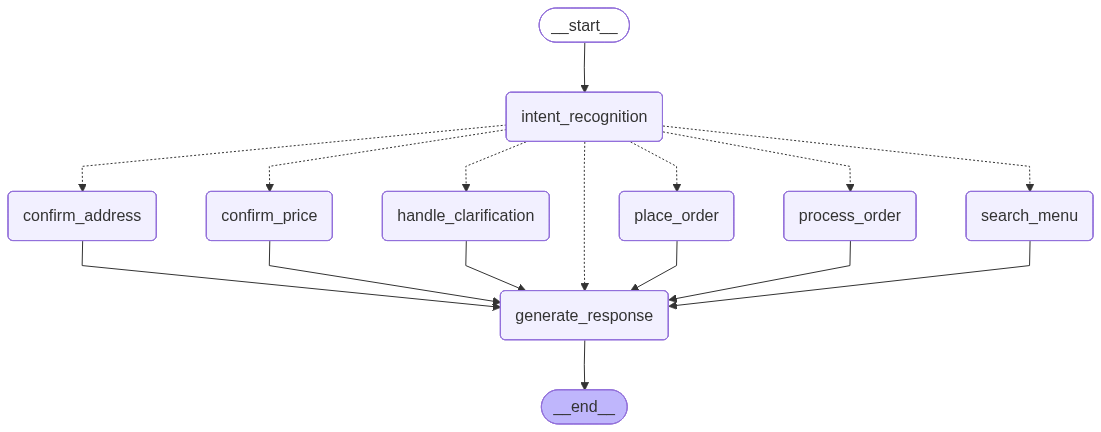

In [13]:
agent.graph.map
agent.graph

In [52]:
agent = RestaurantAgent(Restaurant_menu, mercury2, rerankModel, intentRecog, entityExtracter)
agent.is_llm_analyze_intent = True  # 启用LLM分析意图
agent.run()


🤖 客服: 您好！欢迎致电美味餐厅，我是AI客服小美。请问今天想吃什么？
我可以幫你點餐，有什麽需要？


Traceback (most recent call last):
  File "c:\Users\PC\anaconda_projects\ai_food_order\order_agent.py", line 20, in run
  File "c:\Users\PC\anaconda_projects\ai_food_order\order_agent.py", line 690, in process
    "customer_info": {
              ^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\site-packages\langgraph\pregel\main.py", line 3094, in invoke
    for chunk in self.stream(
                 ~~~~~~~~~~~^
        input,
        ^^^^^^
    ...<10 lines>...
        **kwargs,
        ^^^^^^^^^
    ):
    ^
  File "c:\Users\PC\anaconda3\Lib\site-packages\langgraph\pregel\main.py", line 2669, in stream
    for _ in runner.tick(
             ~~~~~~~~~~~^
        [t for t in loop.tasks.values() if not t.writes],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        schedule_task=loop.accept_push,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ):
    ^
  File "c:\Users\PC\anaconda3\Lib\site-packages\langgraph\pregel\_runner.py", line 167, in tick
    run_with_re

In [35]:
agent = RestaurantAgent(Restaurant_menu, mercury2, rerankModel, intentRecog, entityExtracter)

In [23]:
agent.llm.chat("来份麻婆豆腐")

{'id': 'chatcmpl-75219e1f-c6c8-486f-b065-2a83c5c534eb',
 'object': 'chat.completion',
 'created': 1773072202,
 'model': 'mercury-2',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '好的，已为您准备点麻婆豆腐的订单。请您提供以下信息，以便我们完成下单：\n\n1. **份数**（例如 1 份、2 份）  \n2. **送餐地址**  \n3. **联系电话**  \n4. **是否有特殊需求**（如少辣、加豆腐、去花生等）  \n\n如果您还想再点其他菜品，也可以一起告诉我。谢谢！',
    'tool_calls': None,
    'tool_call_id': None},
   'finish_reason': 'stop'}],
 'usage': {'prompt_tokens': 37,
  'reasoning_tokens': 81,
  'completion_tokens': 95,
  'total_tokens': 213,
  'cached_input_tokens': 3},
 'warning': None,
 'reasoning_summary': {'content': None, 'status': 'unavailable'}}

In [36]:
agent.intent_recognizer.llm_analyze_intent("你好")

'greeting'